<a href="https://colab.research.google.com/github/theyuvrajtayal21-design/COE_Module/blob/main/Copy_of_Module_4_%E2%80%93_Activity_4_1_Data_Cleaning_%26_Preprocessing_Lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Module 4** – Activity 4.1

***Data Cleaning & Preprocessing Lab***

Name: Yuvraj

Roll No.: BETN1AI25101

**Course: Data Analytics Using Python (AIL0202)**


In [ ]:
# Task 1: Missing Values
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

data = {
    'Age': [25, np.nan, 30, 35, np.nan],
    'Salary': [50000, 60000, np.nan, 80000, 75000]
}
df = pd.DataFrame(data)

print("Original Data:")
print(df)

# Identify missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Fill missing values using mean
df_filled = df.fillna(df.mean(numeric_only=True))

print("\nData after filling missing values with mean:")
print(df_filled)

Original Data:
    Age   Salary
0  25.0  50000.0
1   NaN  60000.0
2  30.0      NaN
3  35.0  80000.0
4   NaN  75000.0

Missing values in each column:
Age       2
Salary    1
dtype: int64

Data after filling missing values with mean:
    Age   Salary
0  25.0  50000.0
1  30.0  60000.0
2  30.0  66250.0
3  35.0  80000.0
4  30.0  75000.0


Original Data:
   Salary
0   50000
1   52000
2   58000
3   60000
4  120000


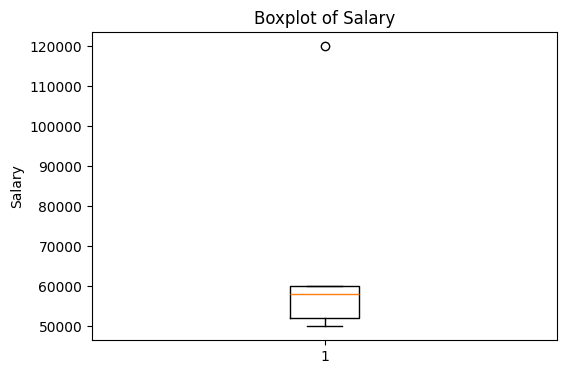


Lower Bound: 40000.0
Upper Bound: 72000.0

Outliers detected:
   Salary
4  120000

Data after removing outliers:
   Salary
0   50000
1   52000
2   58000
3   60000


In [ ]:
# Task 2: Outlier Detection
df = pd.DataFrame({
    'Salary': [50000, 52000, 58000, 60000, 120000]
})

print("Original Data:")
print(df)

# Plot boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(df['Salary'])
plt.title("Boxplot of Salary")
plt.ylabel("Salary")
plt.show()

# Apply IQR method to remove outliers
Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['Salary'] < lower_bound) | (df['Salary'] > upper_bound)]
print("\nOutliers detected:")
print(outliers)

df_clean = df[(df['Salary'] >= lower_bound) & (df['Salary'] <= upper_bound)]
print("\nData after removing outliers:")
print(df_clean)

In [ ]:
# Task 3: Data Scaling
scaler = StandardScaler()

data = [[10], [20], [30], [40], [50]]
scaled_data = scaler.fit_transform(data)

print("Scaled Data:")
print(scaled_data)

Scaled Data:
[[-1.41421356]
 [-0.70710678]
 [ 0.        ]
 [ 0.70710678]
 [ 1.41421356]]


In [ ]:
# Task 4: Data Leakage Identification

# Mistake:
# scaler.fit_transform(X) on the full dataset before splitting causes data leakage.

# Correct code:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = [[10], [20], [30], [40], [50]]
y = [1, 0, 1, 0, 1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train scaled data:")
print(X_train_scaled)

print("\nTest scaled data:")
print(X_test_scaled)

Train scaled data:
[[ 1.18321596]
 [-0.16903085]
 [-1.52127766]
 [ 0.50709255]]

Test scaled data:
[[-0.84515425]]


In [ ]:
# Task 5: Mini Case Study
data = {
    'Age': [22, 25, 47, 52, 46],
    'Income': [15000, 18000, 65000, 72000, 69000]
}
df = pd.DataFrame(data)

print("Original Data:")
print(df)

# Normalize income
df['Income_Normalized'] = (df['Income'] - df['Income'].min()) / (df['Income'].max() - df['Income'].min())

print("\nData with normalized income:")
print(df)

# Detect anomalies
Q1 = df['Income'].quantile(0.25)
Q3 = df['Income'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

anomalies = df[(df['Income'] < lower_bound) | (df['Income'] > upper_bound)]
print("\nAnomalies detected in Income:")
print(anomalies)

# Interpretation (comments)
# Income values 65000, 69000, and 72000 are much higher than 15000 and 18000.
# These may indicate a different income group, but they are not necessarily outliers.
# No strong anomaly is detected using IQR in this small dataset.

Original Data:
   Age  Income
0   22   15000
1   25   18000
2   47   65000
3   52   72000
4   46   69000

Data with normalized income:
   Age  Income  Income_Normalized
0   22   15000           0.000000
1   25   18000           0.052632
2   47   65000           0.877193
3   52   72000           1.000000
4   46   69000           0.947368

Anomalies detected in Income:
Empty DataFrame
Columns: [Age, Income, Income_Normalized]
Index: []
